# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros[:3]

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
dados = pd.DataFrame(registros)

print("Primeiros registros:")
display(dados.head())

linhas, colunas = dados.shape
print(f"\nQuantidade de linhas: {linhas}")
print(f"Quantidade de colunas: {colunas}")

print("\nNomes dos atributos:")
print(dados.columns.tolist())

print("\nInformações do DataFrame:")
dados.info()

print("\nEstatísticas descritivas:")
display(dados.describe(include="all"))

Primeiros registros:


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0



Quantidade de linhas: 336
Quantidade de colunas: 11

Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-nul

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


### Identificação dos atributos principais

- `dat_referencia`: data à qual a medição pertence.
- `din_referenciautc`: data e horário da medição em UTC.
- `cod_areacarga`: código da área de carga analisada; neste caso, `SP`.
- `val_cargaglobal`: valor da carga elétrica global, expresso em MW.
- `din_atualizacao`: momento em que o registro foi atualizado na base. Não representa o horário da medição.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [7]:
dados_renomeados = dados.rename(columns={
    "dat_referencia": "data_referencia",
    "din_referenciautc": "data_hora_utc",
    "cod_areacarga": "area_carga",
    "val_cargaglobal": "carga_mw"
})

colunas_necessarias = [
    "data_referencia",
    "data_hora_utc",
    "area_carga",
    "carga_mw"
]

colunas_ausentes = [
    coluna for coluna in colunas_necessarias
    if coluna not in dados_renomeados.columns
]

if colunas_ausentes:
    raise KeyError(
        f"Colunas esperadas não encontradas: {colunas_ausentes}. "
        f"Colunas disponíveis: {dados_renomeados.columns.tolist()}"
    )

dados_tratados = dados_renomeados[colunas_necessarias].copy()

print("DataFrame com os atributos necessários:")
display(dados_tratados.head())

print("\nValores ausentes antes do tratamento:")
print(dados_tratados.isna().sum())

print("\nTipos antes do tratamento:")
print(dados_tratados.dtypes)

dados_tratados["carga_mw"] = pd.to_numeric(
    dados_tratados["carga_mw"]
        .astype(str)
        .str.replace(",", ".", regex=False),
    errors="coerce"
)

dados_tratados["data_referencia"] = pd.to_datetime(
    dados_tratados["data_referencia"],
    errors="coerce"
)

dados_tratados["data_hora_utc"] = pd.to_datetime(
    dados_tratados["data_hora_utc"],
    errors="coerce",
    utc=True
)

dados_tratados = dados_tratados.dropna(
    subset=["data_referencia", "data_hora_utc", "carga_mw"]
).copy()

print("\nValores ausentes após o tratamento:")
print(dados_tratados.isna().sum())

print("\nTipos após o tratamento:")
print(dados_tratados.dtypes)

print("\nInformações finais do DataFrame:")
dados_tratados.info()

display(dados_tratados.head())

DataFrame com os atributos necessários:


,data_referencia,data_hora_utc,area_carga,carga_mw
0,2025-08-01,2025-08-01T03:30:00.000Z,SP,15913.618
1,2025-08-01,2025-08-01T04:00:00.000Z,SP,15251.414
2,2025-08-01,2025-08-01T04:30:00.000Z,SP,14606.733
3,2025-08-01,2025-08-01T05:00:00.000Z,SP,14182.290
4,2025-08-01,2025-08-01T05:30:00.000Z,SP,13838.488



Valores ausentes antes do tratamento:
data_referencia    0
data_hora_utc      0
area_carga         0
carga_mw           0
dtype: int64

Tipos antes do tratamento:
data_referencia     object
data_hora_utc       object
area_carga          object
carga_mw           float64
dtype: object

Valores ausentes após o tratamento:
data_referencia    0
data_hora_utc      0
area_carga         0
carga_mw           0
dtype: int64

Tipos após o tratamento:
data_referencia         datetime64[ns]
data_hora_utc      datetime64[ns, UTC]
area_carga                      object
carga_mw                       float64
dtype: object

Informações finais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   data_referencia  336 non-null    datetime64[ns]     
 1   data_hora_utc    336 non-null    datetime64[ns, UTC]
 2   area_carg

,data_referencia,data_hora_utc,area_carga,carga_mw
0,2025-08-01,2025-08-01 03:30:00+00:00,SP,15913.618
1,2025-08-01,2025-08-01 04:00:00+00:00,SP,15251.414
2,2025-08-01,2025-08-01 04:30:00+00:00,SP,14606.733
3,2025-08-01,2025-08-01 05:00:00+00:00,SP,14182.290
4,2025-08-01,2025-08-01 05:30:00+00:00,SP,13838.488


### Decisões de tratamento

Os atributos foram renomeados para facilitar a leitura. `carga_mw` foi convertida para número, enquanto `data_referencia` e `data_hora_utc` foram convertidas para tipos de data. O sufixo `_utc` foi mantido para deixar explícito o fuso horário da API. Registros cuja data, horário ou carga não pudessem ser convertidos seriam removidos. Na consulta executada, não foram encontrados valores ausentes nessas colunas.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [8]:
carga_minima = dados_tratados["carga_mw"].min()
carga_maxima = dados_tratados["carga_mw"].max()
carga_media = dados_tratados["carga_mw"].mean()
carga_mediana = dados_tratados["carga_mw"].median()
amplitude = carga_maxima - carga_minima
quantidade_registros = len(dados_tratados)
distancia_maximo_media = ((carga_maxima / carga_media) - 1) * 100

print(f"Carga mínima: {carga_minima:.3f} MW")
print(f"Carga máxima: {carga_maxima:.3f} MW")
print(f"Carga média: {carga_media:.3f} MW")
print(f"Mediana: {carga_mediana:.3f} MW")
print(f"Amplitude: {amplitude:.3f} MW")
print(f"Quantidade total de medições: {quantidade_registros}")
print(f"Máximo acima da média: {distancia_maximo_media:.2f}%")

Carga mínima: 12139.253 MW
Carga máxima: 23185.312 MW
Carga média: 17870.829 MW
Mediana: 18199.128 MW
Amplitude: 11046.059 MW
Quantidade total de medições: 336
Máximo acima da média: 29.74%


### Interpretação dos indicadores

O valor máximo está aproximadamente 30% acima da média. Portanto, ele é claramente superior ao comportamento médio, mas não aparece como um valor isolado sem relação com o restante da série. A mediana próxima da média também indica que o centro da distribuição não está sendo fortemente deslocado por poucos valores extremos.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [9]:
limiar_alta_demanda = carga_maxima * 0.90

dados_alta_demanda = dados_tratados[
    dados_tratados["carga_mw"] > limiar_alta_demanda
].copy()

quantidade_alta_demanda = len(dados_alta_demanda)
percentual_alta_demanda = (
    quantidade_alta_demanda / quantidade_registros
) * 100

indice_pico = dados_tratados["carga_mw"].idxmax()
registro_pico = dados_tratados.loc[indice_pico]
valor_pico = registro_pico["carga_mw"]
momento_pico_utc = registro_pico["data_hora_utc"]
momento_pico_sp = momento_pico_utc.tz_convert("America/Sao_Paulo")

print(f"Limiar de alta demanda: {limiar_alta_demanda:.3f} MW")
print(f"Registros de alta demanda: {quantidade_alta_demanda}")
print(f"Percentual em relação ao total: {percentual_alta_demanda:.2f}%")
print(f"Maior valor de carga: {valor_pico:.3f} MW")
print(f"Momento do pico em UTC: {momento_pico_utc}")
print(f"Momento do pico em São Paulo: {momento_pico_sp}")

display(dados_alta_demanda.head(10))

Limiar de alta demanda: 20866.781 MW
Registros de alta demanda: 50
Percentual em relação ao total: 14.88%
Maior valor de carga: 23185.312 MW
Momento do pico em UTC: 2025-08-01 22:00:00+00:00
Momento do pico em São Paulo: 2025-08-01 19:00:00-03:00


,data_referencia,data_hora_utc,area_carga,carga_mw
35,2025-08-01,2025-08-01 21:00:00+00:00,SP,21088.959
36,2025-08-01,2025-08-01 21:30:00+00:00,SP,22398.360
37,2025-08-01,2025-08-01 22:00:00+00:00,SP,23185.312
38,2025-08-01,2025-08-01 22:30:00+00:00,SP,22903.314
39,2025-08-01,2025-08-01 23:00:00+00:00,SP,22358.701
40,2025-08-01,2025-08-01 23:30:00+00:00,SP,21697.979
41,2025-08-01,2025-08-02 00:00:00+00:00,SP,21385.326
42,2025-08-01,2025-08-02 00:30:00+00:00,SP,20919.314
84,2025-08-02,2025-08-02 21:30:00+00:00,SP,20983.484
85,2025-08-02,2025-08-02 22:00:00+00:00,SP,21202.566


### Interpretação da alta demanda

Os registros de alta demanda representam cerca de 15% das medições. Assim, os períodos próximos ao pico formam uma parcela pequena do período total analisado.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [10]:
# Segundo critério escolhido: carga acima da média
dados_acima_media = dados_tratados[
    dados_tratados["carga_mw"] > carga_media
].copy()

quantidade_acima_media = len(dados_acima_media)
percentual_acima_media = (
    quantidade_acima_media / quantidade_registros
) * 100

indices_sobrepostos = dados_alta_demanda.index.intersection(
    dados_acima_media.index
)
quantidade_sobreposicao = len(indices_sobrepostos)

print(f"Critério escolhido: carga acima da média ({carga_media:.3f} MW)")
print(f"Registros acima da média: {quantidade_acima_media}")
print(f"Percentual em relação ao total: {percentual_acima_media:.2f}%")
print(
    f"Alta demanda: {quantidade_alta_demanda} registros "
    f"({percentual_alta_demanda:.2f}%)"
)
print(f"Sobreposição entre os critérios: {quantidade_sobreposicao} registros")

display(dados_acima_media.head(10))

Critério escolhido: carga acima da média (17870.829 MW)
Registros acima da média: 184
Percentual em relação ao total: 54.76%
Alta demanda: 50 registros (14.88%)
Sobreposição entre os critérios: 50 registros


,data_referencia,data_hora_utc,area_carga,carga_mw
15,2025-08-01,2025-08-01 11:00:00+00:00,SP,18096.023
16,2025-08-01,2025-08-01 11:30:00+00:00,SP,18629.395
17,2025-08-01,2025-08-01 12:00:00+00:00,SP,18825.176
18,2025-08-01,2025-08-01 12:30:00+00:00,SP,19056.504
19,2025-08-01,2025-08-01 13:00:00+00:00,SP,19427.822
20,2025-08-01,2025-08-01 13:30:00+00:00,SP,19648.512
21,2025-08-01,2025-08-01 14:00:00+00:00,SP,19987.754
22,2025-08-01,2025-08-01 14:30:00+00:00,SP,20126.986
23,2025-08-01,2025-08-01 15:00:00+00:00,SP,20126.970
24,2025-08-01,2025-08-01 15:30:00+00:00,SP,19785.258


### Comparação dos critérios

O critério “carga acima da média” é menos restritivo e seleciona pouco mais da metade das medições. Todos os registros classificados como alta demanda também estão acima da média, mas apenas parte dos registros acima da média ultrapassa 90% da carga máxima.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

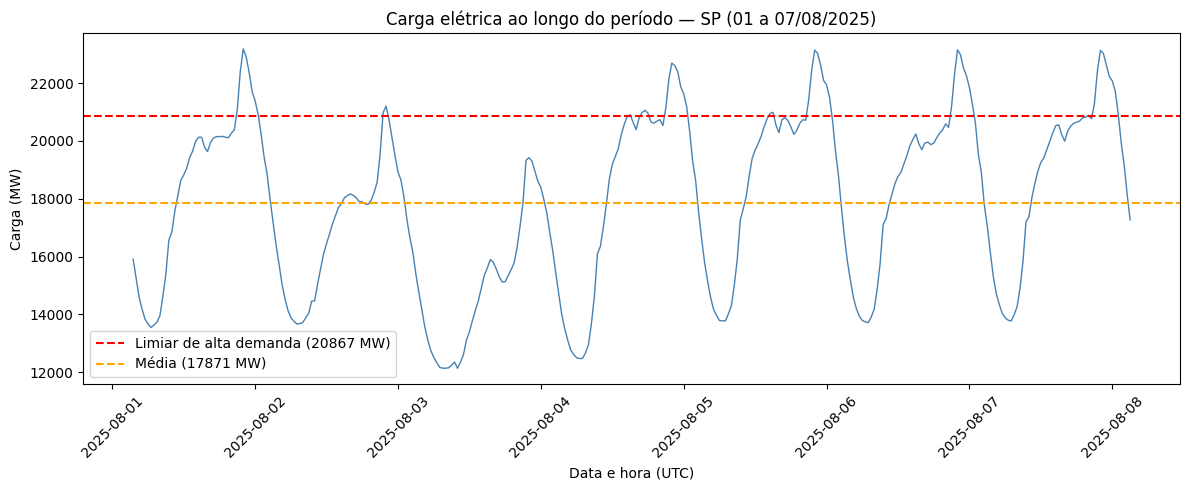

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(
    dados_tratados["data_hora_utc"],
    dados_tratados["carga_mw"],
    linewidth=1,
    color="steelblue"
)
plt.axhline(
    limiar_alta_demanda,
    linestyle="--",
    color="red",
    label=f"Limiar de alta demanda ({limiar_alta_demanda:.0f} MW)"
)
plt.axhline(
    carga_media,
    linestyle="--",
    color="orange",
    label=f"Média ({carga_media:.0f} MW)"
)
plt.xlabel("Data e hora (UTC)")
plt.ylabel("Carga (MW)")
plt.title("Carga elétrica ao longo do período — SP (01 a 07/08/2025)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretação do Gráfico 1:** a série apresenta variações que se repetem ao longo dos dias. Os períodos acima da linha vermelha correspondem à alta demanda definida como carga superior a 90% do máximo.

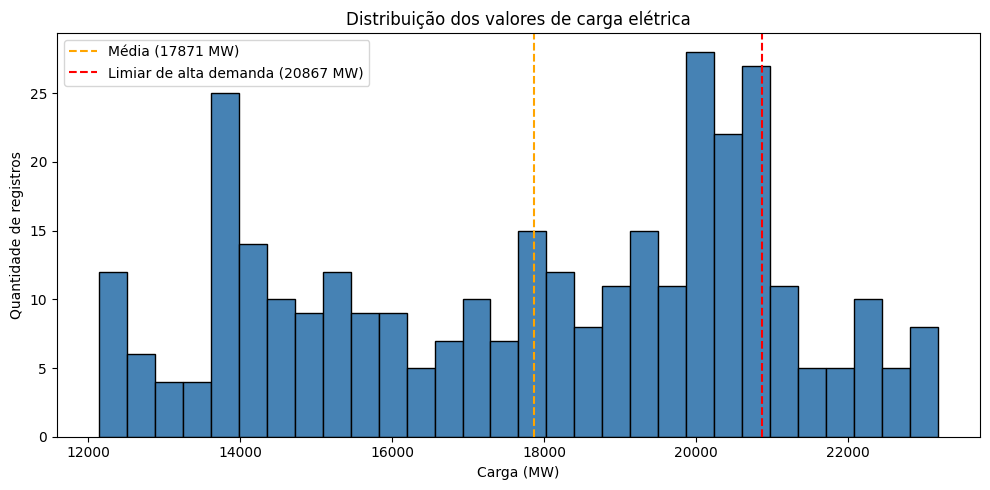

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(
    dados_tratados["carga_mw"],
    bins=30,
    color="steelblue",
    edgecolor="black"
)
plt.axvline(
    carga_media,
    linestyle="--",
    color="orange",
    label=f"Média ({carga_media:.0f} MW)"
)
plt.axvline(
    limiar_alta_demanda,
    linestyle="--",
    color="red",
    label=f"Limiar de alta demanda ({limiar_alta_demanda:.0f} MW)"
)
plt.xlabel("Carga (MW)")
plt.ylabel("Quantidade de registros")
plt.title("Distribuição dos valores de carga elétrica")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretação do Gráfico 2:** a maior concentração de medições ocorre na região central da distribuição, enquanto uma parcela menor alcança valores superiores ao limiar de alta demanda.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [13]:
regiao = "SP — São Paulo"
periodo = "01/08/2025 a 07/08/2025"

resumo_resultados = f"""
Região analisada: {regiao}
Período analisado: {periodo}
Quantidade de registros: {quantidade_registros}

Carga mínima: {carga_minima:.3f} MW
Carga máxima: {carga_maxima:.3f} MW
Carga média: {carga_media:.3f} MW
Mediana: {carga_mediana:.3f} MW
Amplitude: {amplitude:.3f} MW
Máximo acima da média: {distancia_maximo_media:.2f}%

Limiar de alta demanda: {limiar_alta_demanda:.3f} MW
Registros de alta demanda: {quantidade_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.2f}%

Momento do pico em UTC: {momento_pico_utc}
Momento do pico em São Paulo: {momento_pico_sp}
Valor do pico: {valor_pico:.3f} MW

Segundo critério: carga acima da média
Registros acima da média: {quantidade_acima_media}
Percentual acima da média: {percentual_acima_media:.2f}%
Sobreposição entre os critérios: {quantidade_sobreposicao} registros
"""

print(resumo_resultados)


Região analisada: SP — São Paulo
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336

Carga mínima: 12139.253 MW
Carga máxima: 23185.312 MW
Carga média: 17870.829 MW
Mediana: 18199.128 MW
Amplitude: 11046.059 MW
Máximo acima da média: 29.74%

Limiar de alta demanda: 20866.781 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%

Momento do pico em UTC: 2025-08-01 22:00:00+00:00
Momento do pico em São Paulo: 2025-08-01 19:00:00-03:00
Valor do pico: 23185.312 MW

Segundo critério: carga acima da média
Registros acima da média: 184
Percentual acima da média: 54.76%
Sobreposição entre os critérios: 50 registros



# Relatório técnico com apoio do GPT-4o mini

O professor autorizou o uso do **GPT-4o mini** no lugar do Gemini. A integração abaixo utiliza a API da OpenAI e mantém a chave protegida nos **Secrets** do Google Colab.

Antes de executar:

1. abra a opção **Secrets** na barra lateral do Colab;
2. crie um secret chamado `OPENAI_API_KEY`;
3. cole sua chave da OpenAI;
4. permita que o notebook acesse o secret.

**Não escreva a chave diretamente em nenhuma célula.**

In [14]:
!pip -q install -U openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 561.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 13.6 MB/s eta 0:00:00


In [15]:
import openai
from openai import OpenAI
from google.colab import userdata

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError(
        "A chave OPENAI_API_KEY não foi encontrada. "
        "Crie esse secret no Google Colab e permita o acesso do notebook."
    )

client = OpenAI(api_key=OPENAI_API_KEY)

print("Cliente da OpenAI configurado com segurança.")

Cliente da OpenAI configurado com segurança.


## DESAFIO 8 — Geração do relatório com GPT-4o mini

O GPT receberá somente os resultados produzidos nos desafios anteriores. Ele deverá apresentar os indicadores, comparar os dois critérios e evitar explicações causais que não possam ser comprovadas pelos dados.

In [16]:
prompt = f"""
Atue como analista de dados do setor elétrico.

Produza, em português, um relatório técnico curto com base EXCLUSIVAMENTE nos
resultados fornecidos abaixo.

Regras obrigatórias:
- use os valores exatamente como foram fornecidos, sem recalcular ou inventar números;
- informe as unidades em MW;
- diferencie o horário do pico em UTC do horário de São Paulo;
- não invente causas para as variações observadas;
- não atribua as variações ao clima, à economia ou ao comportamento do consumidor;
- diferencie claramente resultados observados de hipóteses;
- não inclua hipóteses na conclusão.

Estruture o relatório em:
1. Caracterização do conjunto analisado;
2. Principais indicadores;
3. Períodos de alta demanda;
4. Comparação com o segundo critério;
5. Conclusão.

RESULTADOS CALCULADOS PELA EQUIPE:

{resumo_resultados}
"""

print(prompt)


Atue como analista de dados do setor elétrico.

Produza, em português, um relatório técnico curto com base EXCLUSIVAMENTE nos
resultados fornecidos abaixo.

Regras obrigatórias:
- use os valores exatamente como foram fornecidos, sem recalcular ou inventar números;
- informe as unidades em MW;
- diferencie o horário do pico em UTC do horário de São Paulo;
- não invente causas para as variações observadas;
- não atribua as variações ao clima, à economia ou ao comportamento do consumidor;
- diferencie claramente resultados observados de hipóteses;
- não inclua hipóteses na conclusão.

Estruture o relatório em:
1. Caracterização do conjunto analisado;
2. Principais indicadores;
3. Períodos de alta demanda;
4. Comparação com o segundo critério;
5. Conclusão.

RESULTADOS CALCULADOS PELA EQUIPE:


Região analisada: SP — São Paulo
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336

Carga mínima: 12139.253 MW
Carga máxima: 23185.312 MW
Carga média: 17870.829 MW
Mediana: 18

In [17]:
response = client.responses.create(
    model="gpt-4o-mini",
    input=prompt
)

relatorio_gpt = response.output_text

print(relatorio_gpt)

# Relatório Técnico: Análise da Demanda de Energia Elétrica em São Paulo

## 1. Caracterização do conjunto analisado

O presente relatório analisa os dados de demanda de energia elétrica na região de São Paulo, no período de 01 a 07 de agosto de 2025. Foram avaliados um total de 336 registros de carga elétrica, permitindo uma compreensão das variações na demanda ao longo desse intervalo.

## 2. Principais indicadores

Os principais indicadores da demanda observada são os seguintes:

- **Carga mínima**: 12139.253 MW
- **Carga máxima**: 23185.312 MW
- **Carga média**: 17870.829 MW
- **Mediana**: 18199.128 MW
- **Amplitude**: 11046.059 MW
- **Máximo acima da média**: 29.74%

## 3. Períodos de alta demanda

Foi definido um limiar de alta demanda em 20866.781 MW. Durante o período analisado, foram registradas 50 ocorrências de alta demanda, representando **14.88%** do total de registros. O pico máximo de carga foi observado em 2025-08-01 às 22:00:00 UTC (19:00:00 em São Paulo), atingindo um

## DESAFIO 9 — Validação crítica

A célula seguinte compara os principais números do relatório gerado pelo GPT com os valores calculados no notebook. Ela também procura expressões que possam indicar causalidade não demonstrada.

In [18]:
import re


def somente_digitos(texto):
    return re.sub(r"\D", "", str(texto))


indicadores_esperados = {
    "quantidade de registros": str(quantidade_registros),
    "carga mínima": f"{carga_minima:.3f}",
    "carga máxima": f"{carga_maxima:.3f}",
    "carga média": f"{carga_media:.3f}",
    "mediana": f"{carga_mediana:.3f}",
    "limiar de alta demanda": f"{limiar_alta_demanda:.3f}",
    "quantidade de alta demanda": str(quantidade_alta_demanda),
    "percentual de alta demanda": f"{percentual_alta_demanda:.2f}",
    "registros acima da média": str(quantidade_acima_media),
    "percentual acima da média": f"{percentual_acima_media:.2f}",
}

relatorio_normalizado = somente_digitos(relatorio_gpt)
resultados_validacao = {}

print("Verificação dos indicadores no relatório do GPT:\n")

for nome, valor in indicadores_esperados.items():
    encontrado = somente_digitos(valor) in relatorio_normalizado
    resultados_validacao[nome] = encontrado
    situacao = "PRESENTE" if encontrado else "AUSENTE — revisar"
    print(f"- {nome}: {situacao}")

expressoes_causais = [
    "devido a",
    "causado por",
    "provocado por",
    "em razão de",
    "por causa de",
]

expressoes_encontradas = [
    expressao
    for expressao in expressoes_causais
    if expressao in relatorio_gpt.lower()
]

print("\nVerificação de causalidade não demonstrada:")

if expressoes_encontradas:
    print("ATENÇÃO — revisar estas expressões:", expressoes_encontradas)
else:
    print("Nenhuma das expressões causais pesquisadas foi encontrada.")

Verificação dos indicadores no relatório do GPT:

- quantidade de registros: PRESENTE
- carga mínima: PRESENTE
- carga máxima: PRESENTE
- carga média: PRESENTE
- mediana: PRESENTE
- limiar de alta demanda: PRESENTE
- quantidade de alta demanda: PRESENTE
- percentual de alta demanda: PRESENTE
- registros acima da média: PRESENTE
- percentual acima da média: PRESENTE

Verificação de causalidade não demonstrada:
Nenhuma das expressões causais pesquisadas foi encontrada.


### Respostas da validação crítica

1. **Os indicadores foram utilizados corretamente?**  
   Sim. Todos os indicadores pesquisados pela célula de validação foram marcados como `PRESENTE`. Os valores de quantidade de registros, mínimo, máximo, média, mediana, limiar, quantidades e percentuais coincidem com os cálculos, os DataFrames e os gráficos.

2. **Há alguma afirmação que não pode ser confirmada pelos dados?**  
   O texto do GPT afirmou que os resultados fornecem uma “base sólida para o acompanhamento e planejamento da demanda energética”. Essa conclusão é mais ampla do que os dados permitem demonstrar. O modelo também utilizou a expressão “consumo de energia elétrica”, embora o atributo analisado represente carga elétrica. Essas formulações foram retiradas ou corrigidas no relatório final.

3. **Houve interpretação exagerada ou causalidade não demonstrada?**  
   Não houve uma explicação causal explícita, mas o GPT chamou o maior valor de “pico significativo”. Como não foi realizado um teste estatístico de significância, a expressão foi substituída apenas por “pico” ou “maior valor”. A versão final não atribui as variações ao clima, à atividade econômica ou ao comportamento dos consumidores.

4. **Que alterações a equipe realizou no texto?**  
   A equipe substituiu “consumo” por “carga elétrica”, retirou a palavra “significativo” e removeu a conclusão excessiva sobre planejamento. Também padronizou as unidades em MW, conferiu os indicadores com os cálculos, diferenciou o horário da medição da data de atualização, manteve os horários em UTC e em São Paulo e evitou qualquer causalidade sem evidência.

## Relatório final revisado

In [19]:
def formatar_numero_br(valor, casas=3):
    numero = f"{valor:,.{casas}f}"
    return numero.replace(",", "X").replace(".", ",").replace("X", ".")


relatorio_final = f"""
ANÁLISE DA CARGA ELÉTRICA DE SÃO PAULO

1. Caracterização do conjunto analisado

Foram analisadas {quantidade_registros} medições de carga elétrica da área
SP — São Paulo, referentes ao período de {periodo}. Os registros foram obtidos
pela API pública de Carga Verificada do Operador Nacional do Sistema Elétrico.

2. Principais indicadores

A carga mínima observada foi de {formatar_numero_br(carga_minima)} MW e a máxima
foi de {formatar_numero_br(carga_maxima)} MW. A média foi de
{formatar_numero_br(carga_media)} MW, enquanto a mediana foi de
{formatar_numero_br(carga_mediana)} MW. A amplitude entre mínimo e máximo foi de
{formatar_numero_br(amplitude)} MW. O valor máximo ficou
{formatar_numero_br(distancia_maximo_media, 2)}% acima da média.

3. Períodos de alta demanda

O limiar de alta demanda foi definido como 90% da carga máxima, correspondendo a
{formatar_numero_br(limiar_alta_demanda)} MW. Foram identificados
{quantidade_alta_demanda} registros acima desse limite, equivalentes a
{formatar_numero_br(percentual_alta_demanda, 2)}% das medições. O pico foi de
{formatar_numero_br(valor_pico)} MW e ocorreu em
{momento_pico_utc.strftime('%d/%m/%Y às %H:%M')} UTC, correspondente a
{momento_pico_sp.strftime('%d/%m/%Y às %H:%M')} no horário de São Paulo.
Portanto, os períodos próximos ao pico representam uma parcela pequena do período
total analisado.

4. Comparação com o segundo critério

Como segundo critério, foram selecionadas as cargas acima da média. Esse recorte
reuniu {quantidade_acima_media} registros, equivalentes a
{formatar_numero_br(percentual_acima_media, 2)}% do total. Todos os
{quantidade_sobreposicao} registros de alta demanda também ficaram acima da
média, confirmando que o critério de 90% do máximo é mais restritivo.

5. Conclusão

A carga apresentou variação ao longo do período, enquanto a alta demanda ficou
concentrada em uma parcela reduzida das medições. Os resultados descrevem o
comportamento observado, mas não permitem determinar suas causas sem dados
adicionais.
"""

print(relatorio_final)


ANÁLISE DA CARGA ELÉTRICA DE SÃO PAULO

1. Caracterização do conjunto analisado

Foram analisadas 336 medições de carga elétrica da área
SP — São Paulo, referentes ao período de 01/08/2025 a 07/08/2025. Os registros foram obtidos
pela API pública de Carga Verificada do Operador Nacional do Sistema Elétrico.

2. Principais indicadores

A carga mínima observada foi de 12.139,253 MW e a máxima
foi de 23.185,312 MW. A média foi de
17.870,829 MW, enquanto a mediana foi de
18.199,128 MW. A amplitude entre mínimo e máximo foi de
11.046,059 MW. O valor máximo ficou
29,74% acima da média.

3. Períodos de alta demanda

O limiar de alta demanda foi definido como 90% da carga máxima, correspondendo a
20.866,781 MW. Foram identificados
50 registros acima desse limite, equivalentes a
14,88% das medições. O pico foi de
23.185,312 MW e ocorreu em
01/08/2025 às 22:00 UTC, correspondente a
01/08/2025 às 19:00 no horário de São Paulo.
Portanto, os períodos próximos ao pico representam uma parcela pequen